In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = pd.read_csv("Boston.csv")   # 讀取 CSV 檔案
df = df.dropna().reset_index(drop=True)  # 去掉缺失值並重置索引

In [16]:
y = df['crim']
X = df.drop('crim', axis=1)

=== Simple Linear Regression ===
zn: coef = -0.0739, p-value = 0.0000


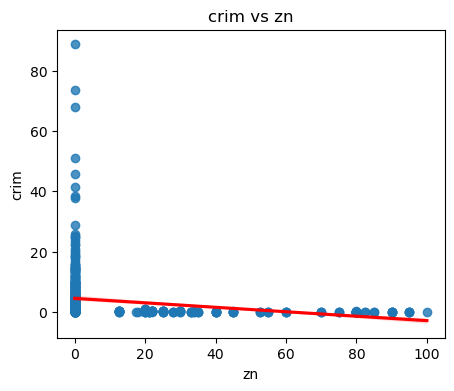

indus: coef = 0.5098, p-value = 0.0000


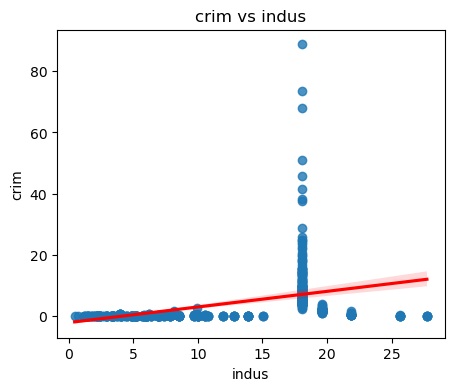

chas: coef = -1.8928, p-value = 0.2094


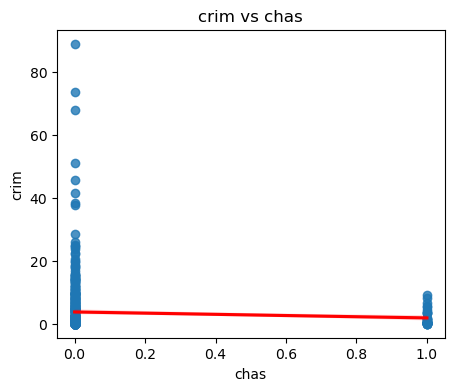

nox: coef = 31.2485, p-value = 0.0000


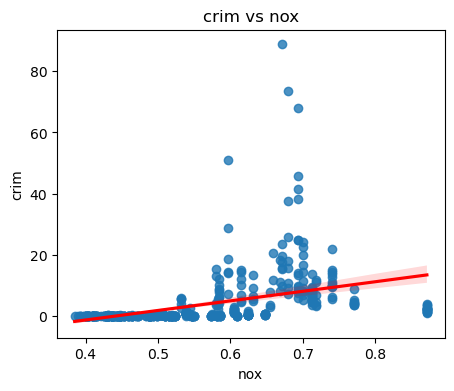

rm: coef = -2.6841, p-value = 0.0000


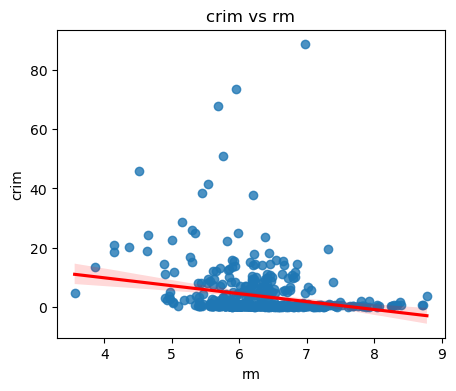

age: coef = 0.1078, p-value = 0.0000


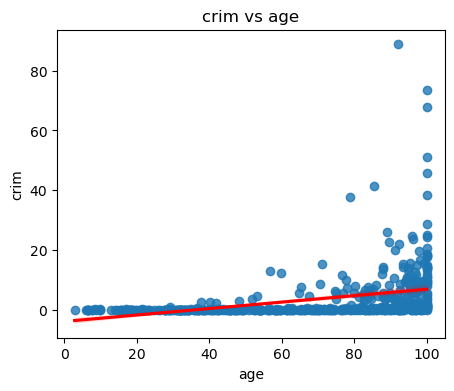

dis: coef = -1.5509, p-value = 0.0000


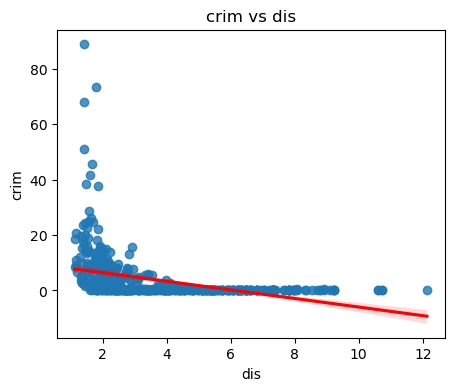

rad: coef = 0.6179, p-value = 0.0000


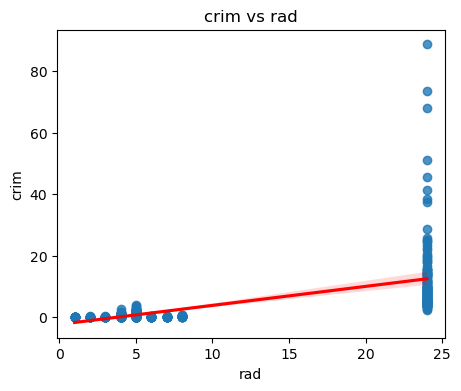

tax: coef = 0.0297, p-value = 0.0000


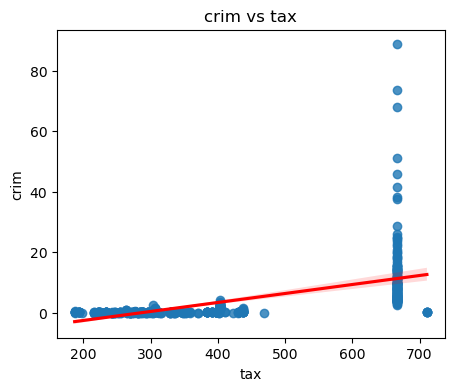

ptratio: coef = 1.1520, p-value = 0.0000


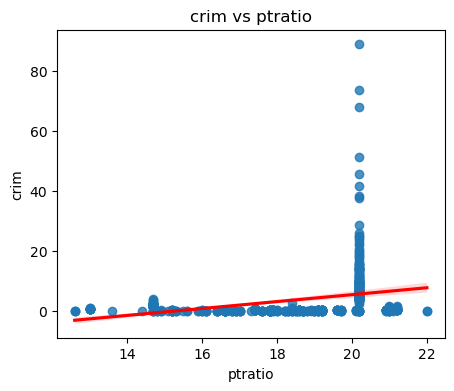

lstat: coef = 0.5488, p-value = 0.0000


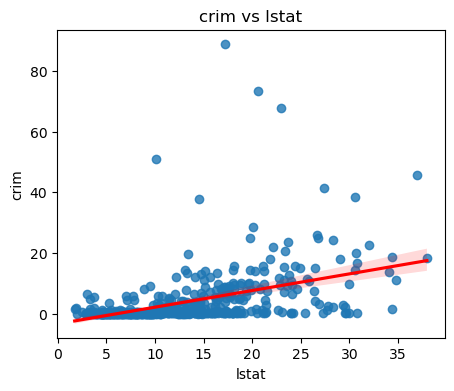

medv: coef = -0.3632, p-value = 0.0000


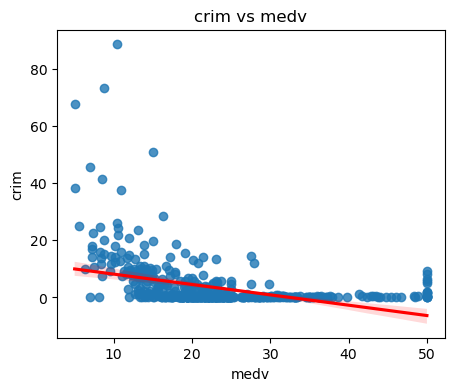

In [18]:
print("=== Simple Linear Regression ===")
simple_coefs = {}

for col in X.columns:
    X_col = sm.add_constant(X[col])
    model = sm.OLS(y, X_col).fit()
    simple_coefs[col] = model.params[col]
    print(f"{col}: coef = {model.params[col]:.4f}, p-value = {model.pvalues[col]:.4f}")

    plt.figure(figsize=(5,4))
    sns.regplot(x=X[col], y=y, line_kws={'color':'red'})
    plt.xlabel(col)
    plt.ylabel('crim')
    plt.title(f'crim vs {col}')
    plt.show()

In [20]:
X_all = sm.add_constant(X)
model_multi = sm.OLS(y, X_all).fit()
print("\n=== Multiple Linear Regression ===")
print(model_multi.summary())


=== Multiple Linear Regression ===
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.436
Method:                 Least Squares   F-statistic:                     33.52
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           2.03e-56
Time:                        22:11:33   Log-Likelihood:                -1655.4
No. Observations:                 506   AIC:                             3337.
Df Residuals:                     493   BIC:                             3392.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13

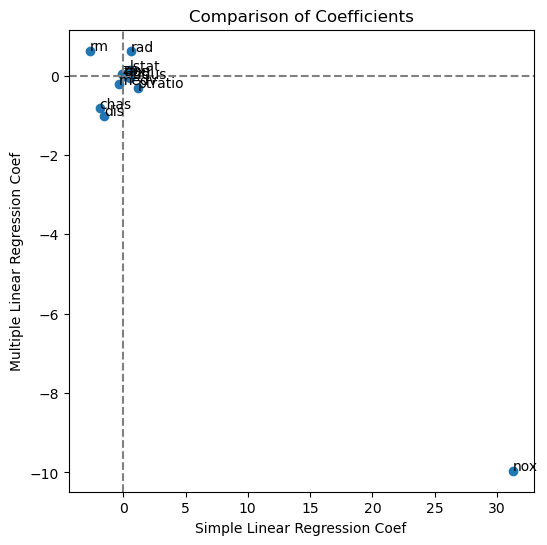

In [34]:
simple_vals = np.array(list(simple_coefs.values()))
multi_vals = np.array(multi_coefs.values)

plt.figure(figsize=(6,6))
plt.scatter(simple_vals, multi_vals)
plt.xlabel("Simple Linear Regression Coef")
plt.ylabel("Multiple Linear Regression Coef")
plt.title("Comparison of Coefficients")
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='gray', linestyle='--')

for i, col in enumerate(simple_coefs.keys()):
    plt.text(simple_vals[i], multi_vals[i], col)

plt.show()


In [30]:
print("\n=== (d) Non-linear check (cubic terms) ===")
for col in X.columns:
    X_poly = sm.add_constant(np.column_stack([X[col], X[col]**2, X[col]**3]))
    model_poly = sm.OLS(y, X_poly).fit()
    print(f"\nPredictor: {col}")
    print(model_poly.summary())


=== (d) Non-linear check (cubic terms) ===

Predictor: zn
                            OLS Regression Results                            
Dep. Variable:                   crim   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     10.35
Date:                Sun, 19 Oct 2025   Prob (F-statistic):           1.28e-06
Time:                        22:14:02   Log-Likelihood:                -1791.2
No. Observations:                 506   AIC:                             3590.
Df Residuals:                     502   BIC:                             3607.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

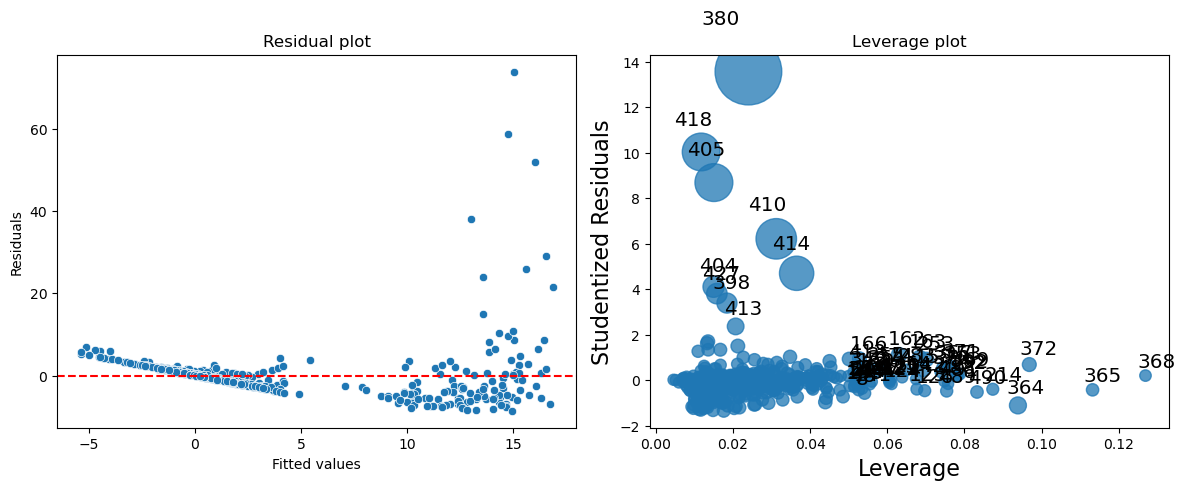

In [32]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

fitted_vals = model_multi.fittedvalues
residuals = model_multi.resid
sns.scatterplot(x=fitted_vals, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')
ax[0].set_title('Residual plot')

sm.graphics.influence_plot(model_multi, ax=ax[1], criterion="cooks")
ax[1].set_title('Leverage plot')
plt.tight_layout()
plt.show()